In [132]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [57]:
block_size = 3
X, Y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
C = torch.randn((27,2))
C[X].shape

torch.Size([32, 3, 2])

In [7]:
X[13,2]

tensor(1)

In [8]:
C[X][13,2]

tensor([ 1.6663, -1.2735])

In [9]:
C[1]

tensor([ 1.6663, -1.2735])

In [12]:
emb = C[X]

W1 = torch.randn((6, 100))
b1 = torch.randn(100)

torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape

torch.Size([32, 6])

In [16]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [17]:
emb.view(32, 6).shape

torch.Size([32, 6])

In [18]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [37]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [42]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([32, 27])

In [43]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(53.7773)

In [107]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [101]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()
loss

tensor(2.9391, grad_fn=<NegBackward0>)

In [48]:
F.cross_entropy(logits, Y) # calculates max value in logits and subtracts from all logits. well-behaved.
                           # -> pass and <- pass are also more efficient

tensor(17.7697)

In [108]:
lre = torch.linspace(-2, 0, 1000)
lrs = 10**lre

In [109]:
for p in parameters:
    p.requires_grad = True

lri = []
lossi = []
for i in range(1000):
    # minibatch
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -lrs[i] * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

20.302955627441406
17.54722023010254
19.8983211517334
21.217348098754883
15.598236083984375
19.623987197875977
15.742405891418457
16.61129379272461
19.920135498046875
17.674938201904297
16.89124298095703
15.076691627502441
19.04636001586914
16.904247283935547
17.910385131835938
17.206331253051758
17.964879989624023
16.55345344543457
14.705202102661133
17.865686416625977
13.847596168518066
17.410194396972656
17.17521095275879
16.421112060546875
13.747570037841797
12.67747688293457
16.977317810058594
17.68052101135254
14.919266700744629
11.884943008422852
13.547314643859863
13.329202651977539
13.464000701904297
17.17548942565918
16.434812545776367
13.998987197875977
14.722495079040527
15.305540084838867
14.51912784576416
12.759187698364258
13.492878913879395
15.22801399230957
13.551610946655273
13.9791259765625
13.398171424865723
14.636699676513672
15.188720703125
16.347461700439453
11.046517372131348
10.351069450378418
12.919994354248047
13.156761169433594
12.647920608520508
10.99840164

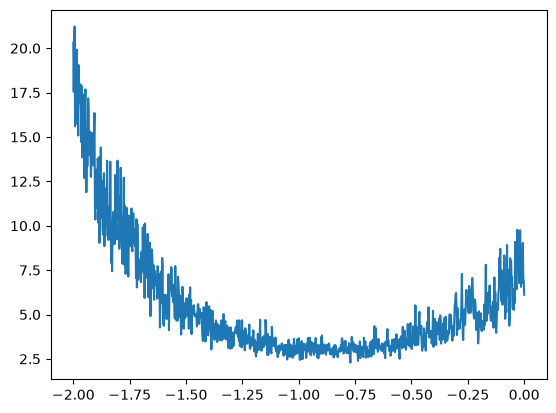

In [110]:
plt.plot(lri, lossi)

In [125]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [130]:
for p in parameters:
    p.requires_grad = True

for i in range(10000):
    # minibatch
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad # implement learning rate decay at the end of training

In [131]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss.item()

2.4067952632904053

In [133]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [197]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [198]:
for p in parameters:
    p.requires_grad = True

In [199]:
lossi = []
stepi = []

In [200]:
for i in range(200000):
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad # implement learning rate decay at the end of training

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

In [191]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.023118019104004


In [192]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.314363479614258

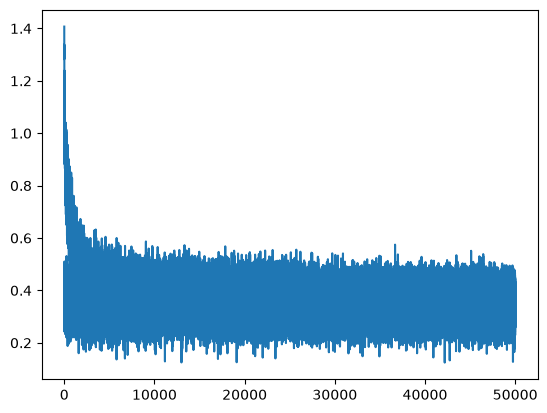

In [193]:
plt.plot(stepi, lossi)

In [201]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carlah.
ambrilli.
kimly.
revilvinah.
sky.
mahnel.
delyah.
jareei.
nellara.
chaiivia.
leigh.
ham.
joce.
quintis.
lilea.
jadii.
watelo.
dearyni.
chaelynn.
diley.
